In [9]:
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset
import ast
import seaborn as sns

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

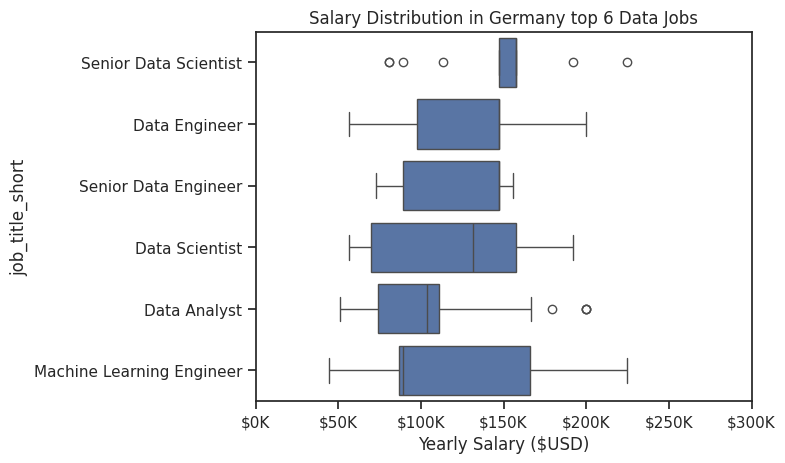

In [10]:
df_GER = df[(df['job_country'] == 'Germany')].dropna(subset=['salary_year_avg']).copy()
job_titles = df_GER['job_title_short'].value_counts().index[:6].tolist()
df_GER_top = df_GER[df_GER['job_title_short'].isin(job_titles)].copy()
job_order = df_GER_top.groupby('job_title_short')['salary_year_avg'].median().sort_values(ascending=False).index

sns.set_theme(style='ticks')
sns.boxplot(data=df_GER_top, x='salary_year_avg', y='job_title_short', order=job_order)
plt.title('Salary Distribution in Germany top 6 Data Jobs')
plt.xlabel('Yearly Salary ($USD)')
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'${int(x/1000)}K'))
plt.xlim(0,300000)
plt.show()


In [11]:
# initial plot, unexpected result (Data Engineer higher median salary than senior roles)
# check job labeling & sample size -> small sample -> unstable result
print(df_GER['job_title_short'].unique())
counts = df_GER_top['job_title_short'].value_counts()
print(counts)

<ArrowStringArray>
[           'Data Scientist',             'Data Engineer',
      'Senior Data Engineer',       'Senior Data Analyst',
              'Data Analyst', 'Machine Learning Engineer',
          'Business Analyst',     'Senior Data Scientist',
         'Software Engineer',            'Cloud Engineer']
Length: 10, dtype: str
job_title_short
Data Analyst                 48
Data Scientist               41
Data Engineer                39
Machine Learning Engineer    39
Senior Data Engineer         26
Senior Data Scientist        21
Name: count, dtype: int64


/tmp/ipykernel_2359/3528376507.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(job_labels)


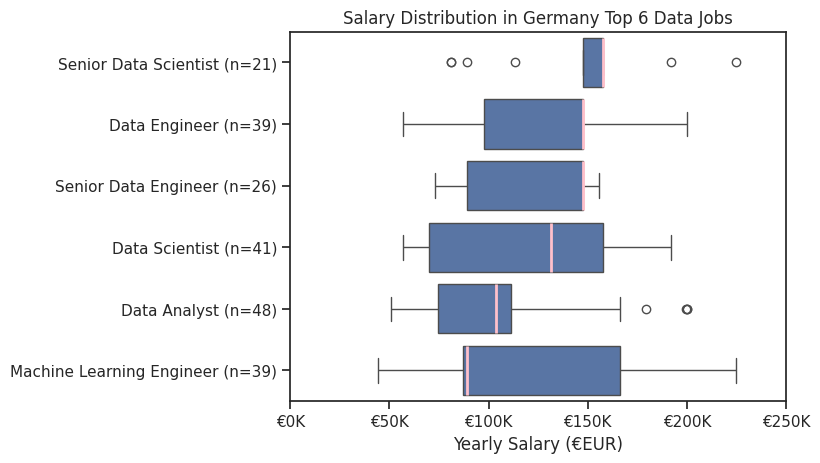

In [12]:
df_GER = df[(df['job_country'] == 'Germany')].dropna(subset=['salary_year_avg']).copy()
job_titles = df_GER['job_title_short'].value_counts().index[:6].tolist()
df_GER_top = df_GER[df_GER['job_title_short'].isin(job_titles)].copy()
job_order = df_GER_top.groupby('job_title_short')['salary_year_avg'].median().sort_values(ascending=False).index
job_labels = [f"{job} (n={counts[job]})" for job in job_order]

sns.set_theme(style='ticks')
sns.boxplot(data=df_GER_top, x='salary_year_avg', y='job_title_short', order=job_order, medianprops={'color': 'pink', 'linewidth': 2})
plt.title('Salary Distribution in Germany Top 6 Data Jobs')
plt.xlabel('Yearly Salary (€EUR)')
plt.ylabel('')
ax = plt.gca()
ax.set_yticklabels(job_labels)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'€{int(x/1000)}K'))
plt.xlim(0,250000)
plt.show()

In [15]:
df_DA_GER = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'] == 'Germany')].dropna(subset=['salary_year_avg']).copy()
df_DA_GER = df_DA_GER.explode('job_skills')
df_DA_GER[['salary_year_avg', 'job_skills']].head()
df_DA_GER['job_skills'].sort_values().unique()

<ArrowStringArray>
[    'atlassian',           'aws',         'azure',      'bigquery',
            'c#',    'databricks', 'elasticsearch',         'excel',
         'flask',           'gcp',           'git',        'github',
            'go',          'java',    'javascript',         'julia',
         'kafka',         'linux',        'looker',        'matlab',
    'matplotlib',         'neo4j',        'no-sql',         'nosql',
         'numpy',        'oracle',        'pandas',        'pascal',
      'power bi',    'powerpoint',       'pyspark',        'python',
             'r',         'react',      'redshift',           'sap',
           'sas',        'sheets',         'spark',           'sql',
    'sql server',       'tableau',      'terminal',     'terraform',
             nan]
Length: 45, dtype: str

In [17]:
# clean double nosql
df_DA_GER['skill_clean'] = df_DA_GER['job_skills'].replace({'no-sql': 'nosql'})

,count,median
skill_clean,,
python,18,111175.0
spark,7,111175.0
pandas,4,108412.5
excel,7,105650.0
sql,24,101500.0
tableau,13,100500.0
power bi,4,83937.5
r,7,75067.5
looker,5,53014.0


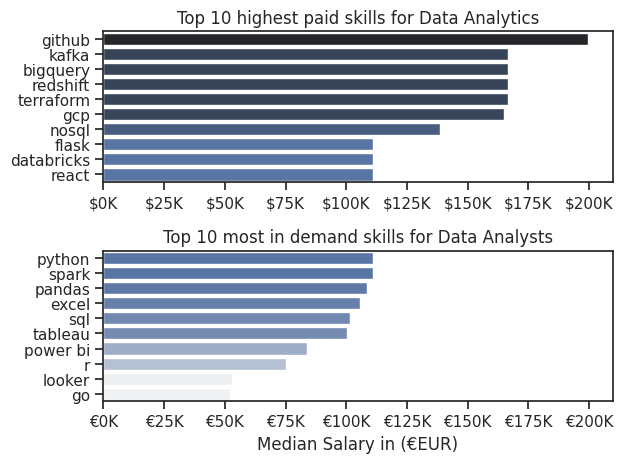

In [19]:
df_DA_GER_group = df_DA_GER.groupby('skill_clean')['salary_year_avg'].agg(['count', 'median'])
df_DA_top = df_DA_GER_group.sort_values(by='median', ascending=False).head(10)
df_DA_skilly = df_DA_GER_group.sort_values(by='count', ascending=False).head(10).sort_values(by='median', ascending=False).head(10)

fig, ax = plt.subplots(2, 1)
sns.barplot(data=df_DA_top, x='median', y=df_DA_top.index, ax=ax[0], hue='median', palette='dark:b_r')
sns.barplot(data=df_DA_skilly, x='median', y=df_DA_skilly.index, ax=ax[1], hue='median', palette='light:b')

ax[0].invert_yaxis()
ax[0].set_title('Top 10 highest paid skills for Data Analytics')
ax[0].set_xlabel('')
ax[0].set_ylabel('')
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))

ax[1].invert_yaxis()
ax[1].set_xlim(ax[0].get_xlim())
ax[1].set_title('Top 10 most in demand skills for Data Analysts')
ax[1].set_ylabel('')
ax[1].set_xlabel('Median Salary in (€EUR)')
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'€{int(x/1000)}K'))
ax[0].yaxis.set_inverted(True)
ax[1].yaxis.set_inverted(True)
ax[0].legend().remove()
ax[1].legend().remove()
sns.set_theme(style='ticks')
fig.tight_layout()
df_DA_skilly
